In [1]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from navigoquest.utils.config import standard_dirs, LEVELS, METADATA_COLS, AGE_RANGE
from navigoquest import format_metric_task_data
from navigoquest.utils.pipelines import load_environment, load_paths_normative, pipeline_compute_features

In [2]:
# Settings common over levels
filename_benchmark = {lvl: f"metrics_level{lvl:02}_gb_2480.csv" for lvl in np.arange(1, 99)}
filename_clinical = "clinical_metrics.csv"
use_sparse_norm = True
metrics_list = ['duration', 'path_length', 'average_curvature', 'boundary_affinity',
             'frobenius_deviation', 'supremum_deviation', 'conformity', 'vector_conformity']
levels_now = [6, 8, 11]
subgroups = ['e3e3', 'e3e4', 'ad']

# Directories
dirs = standard_dirs()
paths_dir = dirs['paths']
output_dir = dirs['output']
if not output_dir.exists():
    output_dir.mkdir(parents=True)

# Load environment
env_store = load_environment(dirs)

# Load benchmark metrics dataframe
benchmark_df = {lvl: pd.read_csv(output_dir / filename_benchmark[lvl]) for lvl in levels_now}

# Load clinical metrics dataframe
clinical_df = pd.read_csv(output_dir / filename_clinical)

Loading environment data...
done. 



In [3]:
# Custom plot function
def plot_overlay_boxplot_groups(ax, arr_ref_all, arr_ind_all, 
                                group_names, subgroup_names, title, 
                                group_spacing=1.0, subgroup_spacing=0.1, jitter=0.03, log_scale=False, show_legend=False):
    plot_colors_indiv = ['green', 'blue', 'orangered']
    markers = ['o', '^', 'D', '^', 's', '*']

    for i, arr_ref in enumerate(arr_ref_all):
        x_center = i * group_spacing

        # Boxplot without outliers
        ax.boxplot(
            arr_ref,
            positions=[x_center],
            widths=0.4,
            showfliers=False
        )

        # Individual arrays
        for j, arr_ind in enumerate(arr_ind_all[i]):
            if i==0:
                label = subgroup_names[j]
            else:
                label = None

            x_vals = x_center + (2+j)*subgroup_spacing + np.random.normal(0, jitter, size=len(arr_ind))
            ax.scatter(
                x_vals,
                arr_ind,
                marker=markers[j % len(markers)],
                s=20,
                alpha=0.9,
                c = plot_colors_indiv[j],
                label=label
            )

    # Plot options
    if log_scale:
        ax.set_yscale("log")
    ax.set_xticks([i * group_spacing for i in range(len(arr_ref_all))])
    ax.set_xticklabels([group_names[i] for i in range(len(arr_ref_all))])
    ax.set_title(title)
    if show_legend:
        ax.legend()


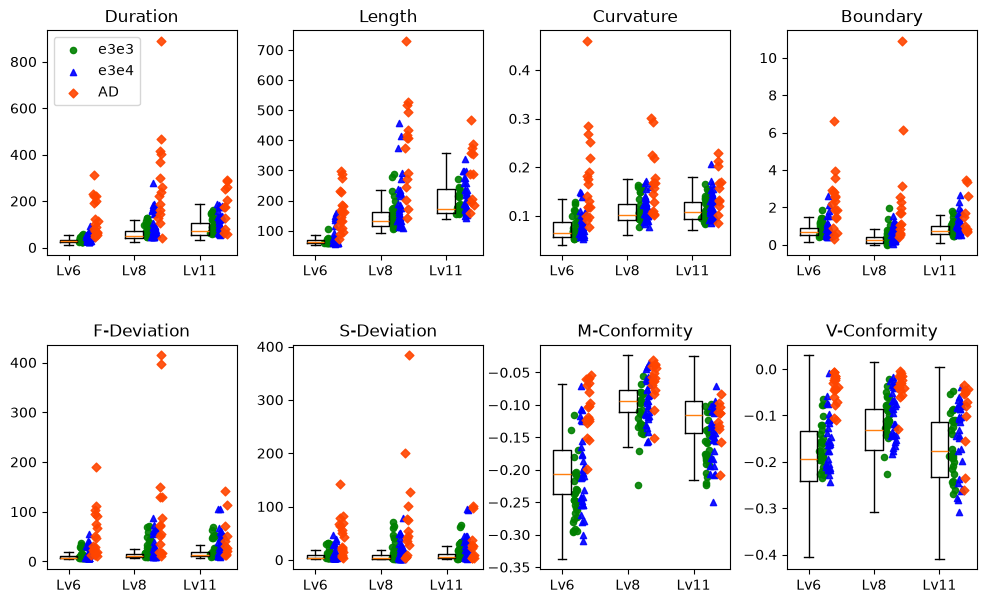

In [5]:
fig, ax = plt.subplots(ncols=4, nrows=2)
fig.set_size_inches(12, 7)
plt.subplots_adjust(wspace=0.3, hspace=0.4)

group_names = ['Lv6', 'Lv8', 'Lv11']
subgroup_names = ['e3e3', 'e3e4', 'AD']
titles = ['Duration', 'Length', 'Curvature', 'Boundary', 'F-Deviation', 'S-Deviation', 'M-Conformity', 'V-Conformity']

for i, metric in enumerate(metrics_list):
    title = titles[i]
    if i == 0:
        show_legend=True
    else:
        show_legend=False

    ax_now = ax[int(i/4), i%4]
    arr_ref_all = [benchmark_df[lvl][metric].to_numpy() for lvl in levels_now]
    arr_ind_all = [[clinical_df[(clinical_df['level'] == lvl) & (clinical_df['group'] == subgp)][metric].to_numpy() for subgp in subgroups] for lvl in levels_now]
    plot_overlay_boxplot_groups(ax_now, arr_ref_all, arr_ind_all, group_names, subgroup_names, title, group_spacing=1.5, subgroup_spacing=0.15, log_scale=False, show_legend=show_legend)